In [2]:
!git clone https://github.com/AnanduDinesan/Facial-Expression-Recognition.git

Cloning into 'Facial-Expression-Recognition'...
remote: Enumerating objects: 34063, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 34063 (delta 1), reused 4 (delta 1), pack-reused 34059 (from 3)
Receiving objects: 100% (34063/34063), 52.50 MiB | 38.73 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (35889/35889), done.


Step 1 — Upload Dataset to Colab

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATASET_PATH = "/content/drive/MyDrive/FER_Hackathon/FER2013"

import libraries

In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [7]:
IMG_SIZE = 48
BATCH_SIZE = 64

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH+"/train",
    color_mode="grayscale",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH+"/test",
    color_mode="grayscale",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [8]:
class_names = train_ds.class_names
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

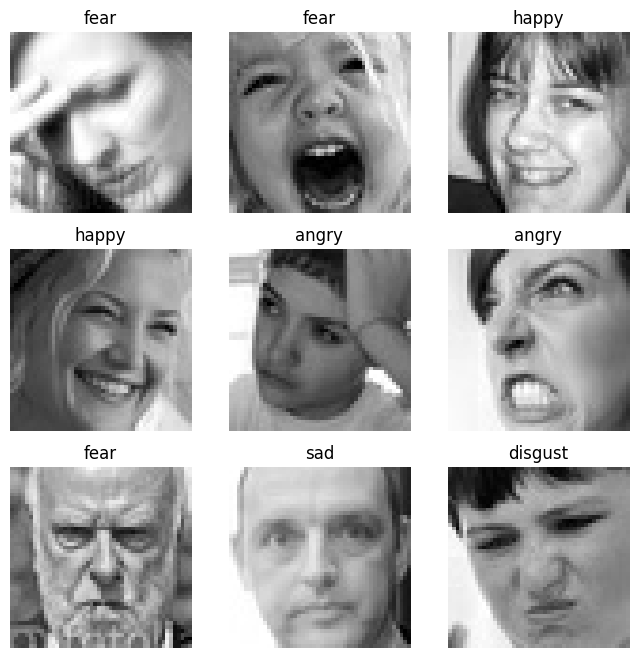

In [10]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[labels[i].numpy().argmax()])
        plt.axis("off")
    plt.show()

# ==============================
# SECTION 2 — DATA ANALYSIS
# ==============================

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

Class distribution: {'surprise': 3171, 'fear': 4097, 'sad': 4830, 'disgust': 436, 'happy': 7215, 'neutral': 4965, 'angry': 3995}


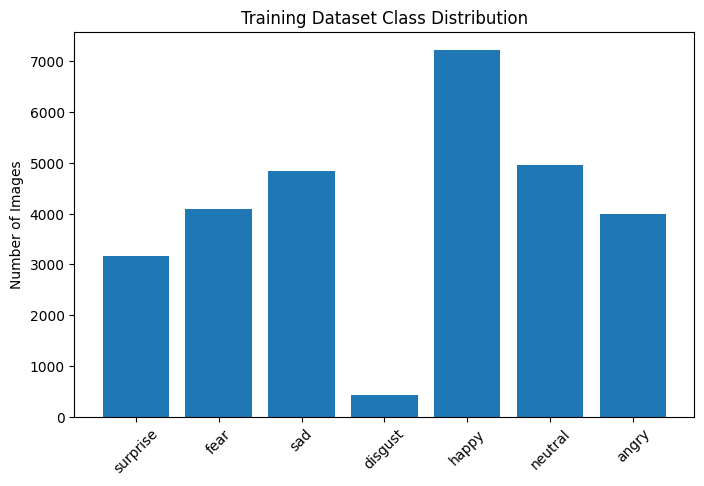

In [12]:
train_path = "/content/Facial-Expression-Recognition/data/train"

class_counts = {}

for cls in os.listdir(train_path):
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

print("Class distribution:", class_counts)

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

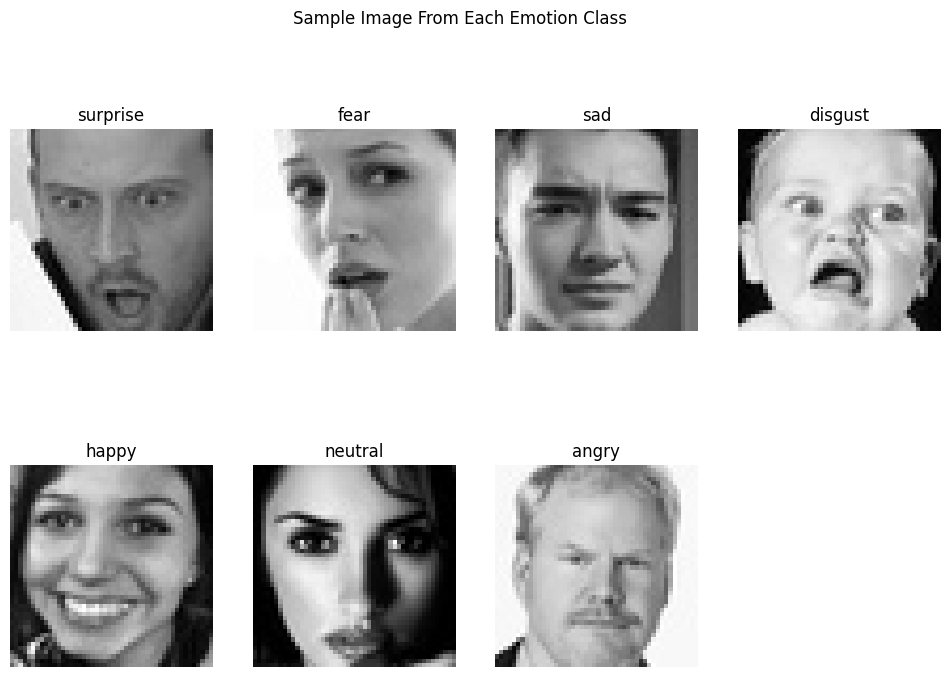

In [13]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(class_counts.keys()):
    folder = os.path.join(train_path, cls)
    img_path = os.path.join(folder, os.listdir(folder)[0])
    img = plt.imread(img_path)

    ax = plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Image From Each Emotion Class")
plt.show()

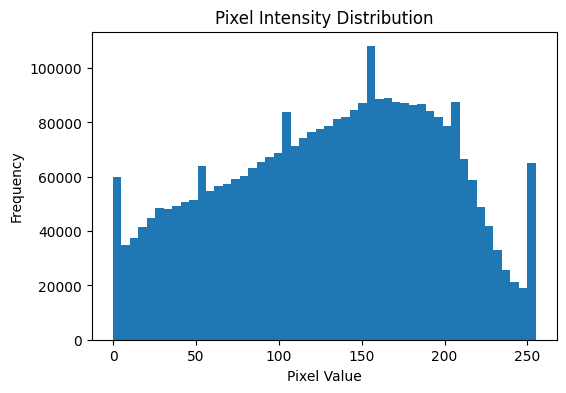

In [14]:
pixel_values = []

for cls in os.listdir(train_path):
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder)[:200]:   # sample only
        img = plt.imread(os.path.join(folder, img_name))
        pixel_values.extend(img.flatten())

plt.figure(figsize=(6,4))
plt.hist(pixel_values, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [15]:
sizes = set()

for cls in os.listdir(train_path):
    folder = os.path.join(train_path, cls)
    for img_name in os.listdir(folder)[:50]:
        img = plt.imread(os.path.join(folder, img_name))
        sizes.add(img.shape)

print("Unique image sizes:", sizes)

Unique image sizes: {(48, 48)}


In [16]:
total_images = sum(class_counts.values())
num_classes = len(class_counts)

print(f"Total training images: {total_images}")
print(f"Number of emotion classes: {num_classes}")

Total training images: 28709
Number of emotion classes: 7
